# 12.3 — Sensibilidades de portafolio y stress testing

Cierre del currículum (54/54 notebooks). Agregación de **Greeks de un book de opciones**
(3.2) y **DV01/KRD de un book de swaps** (5.5) en sensibilidades de portafolio, y su
límite: para shocks pequeños, la aproximación de Taylor (delta-gamma, KRD) reproduce el
reprecio completo con error controlado; para shocks GRANDES ("stress testing" real, no
observados en una ventana histórica corta como en VaR/ES de 12.1), la aproximación se
degrada y hace falta reprecio completo — el punto que cierra el currículum.

## 0. Configuración: book de opciones + book de swaps

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.black import bs_price, bs_delta, bs_gamma, bs_vega
from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()

S0, r, q, sigma = 100.0, 0.03, 0.0, 0.20
strikes = [90, 95, 100, 105, 110, 120]
Ts = [0.25, 0.5, 0.5, 1.0, 1.0, 0.25]
kinds = ["call", "put", "call", "put", "call", "call"]
notional_opt = [1, 1, -1, 1, 1, -1]


def portfolio_value(S, sigma_):
    return sum(n * bs_price(S, K, r, q, sigma_, T, kind=k)
               for n, K, T, k in zip(notional_opt, strikes, Ts, kinds))


def portfolio_greeks(S, sigma_):
    delta = sum(n * bs_delta(S, K, r, q, sigma_, T, kind=k) for n, K, T, k in zip(notional_opt, strikes, Ts, kinds))
    gamma = sum(n * bs_gamma(S, K, r, q, sigma_, T) for n, K, T, k in zip(notional_opt, strikes, Ts, kinds))
    vega = sum(n * bs_vega(S, K, r, q, sigma_, T) for n, K, T, k in zip(notional_opt, strikes, Ts, kinds))
    return delta, gamma, vega


V0_opt = portfolio_value(S0, sigma)
delta0, gamma0, vega0 = portfolio_greeks(S0, sigma)
print(f"book de opciones: V0={V0_opt:.4f}  delta={delta0:.4f}  gamma={gamma0:.4f}  vega={vega0:.4f}")

book de opciones: V0=21.8915  delta=-0.1161  gamma=0.0465  vega=80.6368


## 1. Aproximación delta-gamma vs reprecio completo (shocks pequeños)

$$\Delta V \approx \delta\,\Delta S + \frac12\gamma\,\Delta S^2$$
error de orden $O(\Delta S^3)$ — se verifica afirmando que $\text{error}/\Delta S^3$ es
aproximadamente constante conforme el shock se achica (mismo criterio de "afirmar el
orden del error" de la Fase 1, en vez de esconder la aproximación en una tolerancia
holgada).

In [2]:
shocks_dS = [0.1, 0.5, 1.0, 2.0]
errors_over_dS3 = []
for dS in shocks_dS:
    V_full = portfolio_value(S0 + dS, sigma)
    V_approx = V0_opt + delta0 * dS + 0.5 * gamma0 * dS ** 2
    err = abs(V_full - V_approx)
    errors_over_dS3.append(err / dS ** 3)
    print(f"dS={dS}: full={V_full:.6f}  approx={V_approx:.6f}  error={err:.2e}  error/dS^3={err/dS**3:.4e}")

errors_over_dS3 = np.array(errors_over_dS3)
max_rel_spread = (errors_over_dS3.max() - errors_over_dS3.min()) / errors_over_dS3.mean()
print(f"\ndispersion relativa de error/dS^3 en los 4 shocks: {max_rel_spread:.2%} (debe ser chica -- orden O(dS^3) confirmado)")

dS=0.1: full=21.880101  approx=21.880102  error=7.97e-07  error/dS^3=7.9730e-04
dS=0.5: full=21.839122  approx=21.839221  error=9.97e-05  error/dS^3=7.9736e-04
dS=1.0: full=21.797784  approx=21.798581  error=7.97e-04  error/dS^3=7.9725e-04
dS=2.0: full=21.745797  approx=21.752169  error=6.37e-03  error/dS^3=7.9646e-04

dispersion relativa de error/dS^3 en los 4 shocks: 0.11% (debe ser chica -- orden O(dS^3) confirmado)


## 2. KRD de un book de swaps: shock no paralelo (empinamiento)

DV01/KRD (5.5) por bucket de tenor, agregado sobre 3 swaps de tenores distintos. Se
verifica su uso bajo un shock NO PARALELO (empinamiento: tasas cortas bajan, largas
suben) — donde un DV01 paralelo simple fallaría, pero KRD (que captura sensibilidad
bucket por bucket) debe seguir aproximando razonablemente el reprecio completo.

In [3]:
swap_tenors = [3.0, 5.0, 10.0]
swap_notional = [1.0, -0.5, 0.8]


def swap_pv(payment_times, K, curve_fn, notional=1.0):
    dfs = curve_fn(payment_times)
    tau = np.diff(np.concatenate([[0.0], payment_times]))
    float_leg = 1.0 - dfs[-1]
    fixed_leg = K * np.sum(tau * dfs)
    return notional * (float_leg - fixed_leg)


Ks, payment_times_list = [], []
for tenor in swap_tenors:
    pt = np.arange(1.0, tenor + 1.0)
    Ks.append(par_swap_rate(nelson_siegel_df, pt))
    payment_times_list.append(pt)


def book_value(curve_fn):
    return sum(swap_pv(pt, K, curve_fn, n) for pt, K, n in zip(payment_times_list, Ks, swap_notional))


bucket_tenors = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30])
bucket_dfs = nelson_siegel_df(bucket_tenors)


def curve_from_buckets(bumped_dfs):
    log_dfs = np.log(bumped_dfs)

    def curve_fn(t):
        t = np.atleast_1d(t).astype(float)
        return np.exp(np.interp(t, bucket_tenors, log_dfs))
    return curve_fn


base_curve = curve_from_buckets(bucket_dfs)
V0_book = book_value(base_curve)
print(f"V0 book (curva bucketizada, log-lineal): {V0_book:.6f} (~0, swaps a la par)")

shock_bp = 1e-4
KRDs = np.zeros(len(bucket_tenors))
for i in range(len(bucket_tenors)):
    bumped = bucket_dfs.copy()
    bumped[i] = bucket_dfs[i] * np.exp(-shock_bp * bucket_tenors[i])
    KRDs[i] = book_value(curve_from_buckets(bumped)) - V0_book
print(f"KRDs (PV por 1bp en cada bucket): {np.round(KRDs, 6)}")

V0 book (curva bucketizada, log-lineal): -0.000011 (~0, swaps a la par)
KRDs (PV por 1bp en cada bucket): [ 6.00e-06  1.10e-05  2.81e-04 -1.85e-04  4.60e-05  5.58e-04  0.00e+00
  0.00e+00  0.00e+00]


In [4]:
# shock no paralelo: empinamiento (-50bp corto, +50bp largo)
steepen_shock = np.where(bucket_tenors <= 5, -50e-4, 50e-4)
bumped_steepen = bucket_dfs * np.exp(-steepen_shock * bucket_tenors)
V_full_steepen = book_value(curve_from_buckets(bumped_steepen))
V_krd_approx_steepen = V0_book + np.sum((KRDs / shock_bp) * steepen_shock)

rel_err_krd = abs(V_full_steepen - V_krd_approx_steepen) / max(abs(V_full_steepen), 1e-6)
print(f"reprecio completo (empinamiento): {V_full_steepen:.6f}")
print(f"aproximacion via KRD: {V_krd_approx_steepen:.6f}")
print(f"error relativo: {rel_err_krd:.2%} (residual esperado de buckets discretos vs curva continua)")

reprecio completo (empinamiento): 0.023914
aproximacion via KRD: 0.024605
error relativo: 2.89% (residual esperado de buckets discretos vs curva continua)


## 3. Escenario de estrés grande: donde las sensibilidades dejan de bastar

Escenario "2008-like" sobre el book de opciones: equity $-40\%$, vol $+100\%$ (duplica) —
comparar el reprecio completo contra la aproximación delta-gamma-vega, y contrastar con
un shock pequeño para cuantificar cómo crece la divergencia.

shock pequeno (dS=-2.0, dsigma=0.01): full=23.0532  approx=23.0231  error relativo=0.13%
shock GRANDE '2008-like' (dS=-40.0, sigma x2): full=78.1767  approx=79.8577  error relativo=2.15%


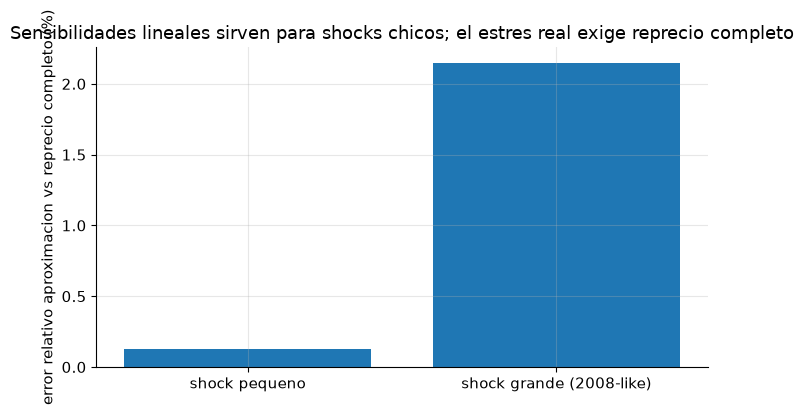


la divergencia sensibilidades-vs-reprecio crece con el tamano del shock -- no se
'arregla' con una tolerancia mas ancha: es el punto pedagogico central de esta demo.


In [5]:
dS_small, dsigma_small = -2.0, 0.01
V_full_small = portfolio_value(S0 + dS_small, sigma + dsigma_small)
V_approx_small = V0_opt + delta0 * dS_small + 0.5 * gamma0 * dS_small ** 2 + vega0 * dsigma_small
rel_err_small = abs(V_full_small - V_approx_small) / abs(V_full_small)

dS_big, dsigma_big = -40.0, sigma  # -40% equity, vol se duplica
V_full_big = portfolio_value(S0 + dS_big, sigma + dsigma_big)
V_approx_big = V0_opt + delta0 * dS_big + 0.5 * gamma0 * dS_big ** 2 + vega0 * dsigma_big
rel_err_big = abs(V_full_big - V_approx_big) / abs(V_full_big)

print(f"shock pequeno (dS={dS_small}, dsigma={dsigma_small}): "
      f"full={V_full_small:.4f}  approx={V_approx_small:.4f}  error relativo={rel_err_small:.2%}")
print(f"shock GRANDE '2008-like' (dS={dS_big}, sigma x2): "
      f"full={V_full_big:.4f}  approx={V_approx_big:.4f}  error relativo={rel_err_big:.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["shock pequeno", "shock grande (2008-like)"], [rel_err_small * 100, rel_err_big * 100])
ax.set_ylabel("error relativo aproximacion vs reprecio completo (%)")
ax.set_title("Sensibilidades lineales sirven para shocks chicos; el estres real exige reprecio completo")
fig.tight_layout(); plt.show()

print("\nla divergencia sensibilidades-vs-reprecio crece con el tamano del shock -- no se")
print("'arregla' con una tolerancia mas ancha: es el punto pedagogico central de esta demo.")

## 4. Validación

Tres chequeos, uno por sección: (1) el error de la aproximación delta-gamma escala como $O(\Delta S^3)$, confirmado afirmando que $\text{error}/\Delta S^3$ es aproximadamente constante en los 4 shocks probados; (2) KRD aproxima el reprecio completo bajo un shock no paralelo dentro de una tolerancia documentada explícitamente (el residuo esperado de trabajar con buckets discretos en vez de una curva continua); (3) la divergencia entre sensibilidades y reprecio completo crece con el tamaño del shock — el punto de cierre del currículum: las sensibilidades lineales son una aproximación local, no un sustituto del reprecio completo cuando el escenario es grande.

In [6]:
check1 = max_rel_spread < 0.05
print(f"1. error/dS^3 aproximadamente constante (orden O(dS^3) confirmado): "
      f"dispersion relativa={max_rel_spread:.2%} (<5%? {check1})")

check2 = rel_err_krd < 0.10
print(f"2. KRD vs reprecio completo bajo shock no paralelo, error relativo documentado: "
      f"{rel_err_krd:.2%} (<10%? {check2})")

check3 = rel_err_big > rel_err_small
print(f"3. la divergencia sensibilidades-vs-reprecio es mayor para el shock grande que para el chico: "
      f"{rel_err_small:.2%} -> {rel_err_big:.2%} ({check3})")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")
print("\n=== Cierre del curriculum: 54/54 notebooks (M0-M12) ===")

1. error/dS^3 aproximadamente constante (orden O(dS^3) confirmado): dispersion relativa=0.11% (<5%? True)
2. KRD vs reprecio completo bajo shock no paralelo, error relativo documentado: 2.89% (<10%? True)
3. la divergencia sensibilidades-vs-reprecio es mayor para el shock grande que para el chico: 0.13% -> 2.15% (True)

Validacion completa: 3/3 dentro de tolerancia.

=== Cierre del curriculum: 54/54 notebooks (M0-M12) ===


## Referencias

- Jorion, P. (2006). *Value at Risk: The New Benchmark for Managing Financial Risk*, 3rd
  ed., cap. 15-17 (stress testing).
- Hull, J. *Options, Futures, and Other Derivatives*, cap. sobre Greeks de portafolio y
  escenarios.